# Assignment 1 — Data and Probability Foundations

## Group members

- Bibek Chaudhary (344326)
- Samo Susa (343876)
- Sneha Koirala (345788)
- Tomas Psotka (343207)

## Table of contents

1. [Part 1 — Digital services](#Part-1-—-Digital-services)
   1. Dataset and variables
   2. Alert-type frequency table
   3. Descriptive latency statistics
   4. Histogram
   5. Side-by-side boxplots
   6. Potential outliers
   7. Comparison of services
   8. Part 1 conclusion
2. [Part 2 — Smart-building measurements](#Part-2-—-Smart-building-measurements)
3. [Part 3 — Cybersecurity alert system](#Part-3-—-Cybersecurity-alert-system)
4. [Part 4 — AI use and overall conclusion](#Part-4-—-AI-use-and-overall-conclusion)


## Imports and display settings

Only methods from Sessions 1–2 are used. Pandas handles the tables and descriptive statistics, while Matplotlib creates the plots. NumPy, SciPy, Seaborn, correlation, regression, confidence intervals, and hypothesis tests are not needed here.


In [4]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    # This fallback is useful if the code is tested as a normal Python script.
    display = print

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.2f}")


# Part 1 — Digital services

## 1.1 Load and inspect the dataset

The assignment asks us to read the file from a local `data` folder. The small fallback list below also allows the notebook to work if it is saved directly inside that folder or one level below it.


In [5]:
candidate_paths = [
    Path("data/assignment01_digital_services.csv"),
    Path("../data/assignment01_digital_services.csv"),
    Path("assignment01_digital_services.csv"),
]

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find assignment01_digital_services.csv. "
        "Place it in a data folder next to this notebook."
    )

digital_services = pd.read_csv(data_path)
print(f"Loaded: {data_path}")
print(f"Rows: {len(digital_services)}, Columns: {digital_services.shape[1]}")
display(digital_services.head())


Loaded: ..\data\assignment01_digital_services.csv
Rows: 144, Columns: 4


,observation_id,service,latency_ms,alert_type
0,1,orders,112.70,none
1,2,orders,109.83,none
2,3,telemetry,99.02,none
3,4,telemetry,94.44,none
4,5,telemetry,97.09,none


In [6]:
print("Column data types:")
display(digital_services.dtypes.rename("Data type").to_frame())

print("Missing values per column:")
display(digital_services.isna().sum().rename("Missing values").to_frame())

print("Number of duplicated observation IDs:")
print(digital_services["observation_id"].duplicated().sum())


Column data types:


,Data type
observation_id,int64
service,str
latency_ms,float64
alert_type,str


Missing values per column:


,Missing values
observation_id,0
service,0
latency_ms,0
alert_type,0


Number of duplicated observation IDs:
0


### Observational unit, population and variables

The **observational unit** is one recorded digital-service observation: one row gives the service involved, its measured latency and the alert category associated with that observation.

The **sample** is the 144 observations in the supplied CSV file. The relevant **population** is all comparable observations from these three digital services in the operating environment and period that the sample is intended to represent. Because the file does not describe a random-sampling design or a wider time frame, generalisation beyond the supplied observations must be cautious.

| Variable | Classification | Reason |
|---|---|---|
| `observation_id` | Categorical identifier | Its numbers label observations; arithmetic on the labels has no useful meaning. |
| `service` | Categorical | It places an observation into a service category: identity, orders or telemetry. |
| `latency_ms` | Quantitative, continuous | It measures elapsed time numerically in milliseconds. |
| `alert_type` | Categorical | It records the alert category, including `none`. |

Although `observation_id` contains integers, it is not a quantitative measurement. For example, ID 100 does not represent twice as much of anything as ID 50.


## 1.2 Frequency table for `alert_type`

Counts tell us how many observations belong to each category. Percentages express each count as a proportion of all 144 observations.


In [7]:
alert_counts = digital_services["alert_type"].value_counts()

alert_frequency = pd.DataFrame({
    "Count": alert_counts,
    "Percentage": alert_counts / len(digital_services) * 100,
})

alert_frequency.loc["Total"] = [
    alert_frequency["Count"].sum(),
    alert_frequency["Percentage"].sum(),
]

alert_frequency["Count"] = alert_frequency["Count"].astype(int)
display(alert_frequency.round(2))


,Count,Percentage
alert_type,,
none,104,72.22
authentication,25,17.36
rate_limit,9,6.25
injection_signature,6,4.17
Total,144,100.00


### Interpretation

The category `none` is the most frequent, with 104 observations (72.22%). Among actual alert categories, `authentication` is the most frequent with 25 observations (17.36%), followed by `rate_limit` with 9 (6.25%). `injection_signature` is the least frequent category with 6 observations (4.17%). These percentages describe the composition of this sample; they do not explain why the categories occur at different frequencies.


## 1.3 Descriptive statistics for `latency_ms`

For each group we calculate the sample size, mean, median, sample standard deviation, minimum, first quartile ($Q_1$), third quartile ($Q_3$), maximum and interquartile range.

$$\operatorname{IQR}=Q_3-Q_1$$

The standard deviation uses $n-1$ in the denominator. In Pandas this is made explicit with `std(ddof=1)`.


In [8]:
def summarise_latency(values):
    # Return the descriptive statistics requested in the assignment.
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    return pd.Series({
        "n": values.count(),
        "Mean": values.mean(),
        "Median": values.median(),
        "Sample SD": values.std(ddof=1),
        "Minimum": values.min(),
        "Q1": q1,
        "Q3": q3,
        "Maximum": values.max(),
        "IQR": q3 - q1,
    })


overall_stats = summarise_latency(
    digital_services["latency_ms"]
).to_frame().T
overall_stats.index = ["All observations"]

service_stats = pd.DataFrame({
    service: summarise_latency(group["latency_ms"])
    for service, group in digital_services.groupby("service")
}).T

latency_statistics = pd.concat([overall_stats, service_stats])
latency_statistics["n"] = latency_statistics["n"].astype(int)

display(latency_statistics.round(2))


,n,Mean,Median,Sample SD,Minimum,Q1,Q3,Maximum,IQR
All observations,144,110.11,106.93,23.10,75.21,95.84,116.88,223.80,21.04
identity,49,96.07,93.72,16.12,75.21,85.39,105.10,154.27,19.71
orders,50,122.20,114.52,24.81,98.53,109.84,124.15,223.80,14.31
telemetry,45,111.97,106.92,19.38,86.78,97.95,116.83,177.87,18.88


### Interpretation

Across all 144 observations, the mean latency is 110.11 ms and the median is 106.93 ms. The overall sample standard deviation is 23.10 ms, and the middle 50% of observations span an IQR of 21.04 ms, from 95.85 ms to 116.88 ms.

The identity service has the lowest typical latency (mean 96.07 ms; median 93.72 ms). Orders has the highest typical latency (mean 122.20 ms; median 114.53 ms), while telemetry lies between them (mean 111.97 ms; median 106.92 ms). Orders also has the largest sample standard deviation at 24.81 ms. However, its IQR is the smallest at 14.31 ms. This combination suggests that the middle half of orders observations is fairly concentrated, while several unusually high values enlarge its overall standard deviation and range.


## 1.4 Histogram of all latency measurements


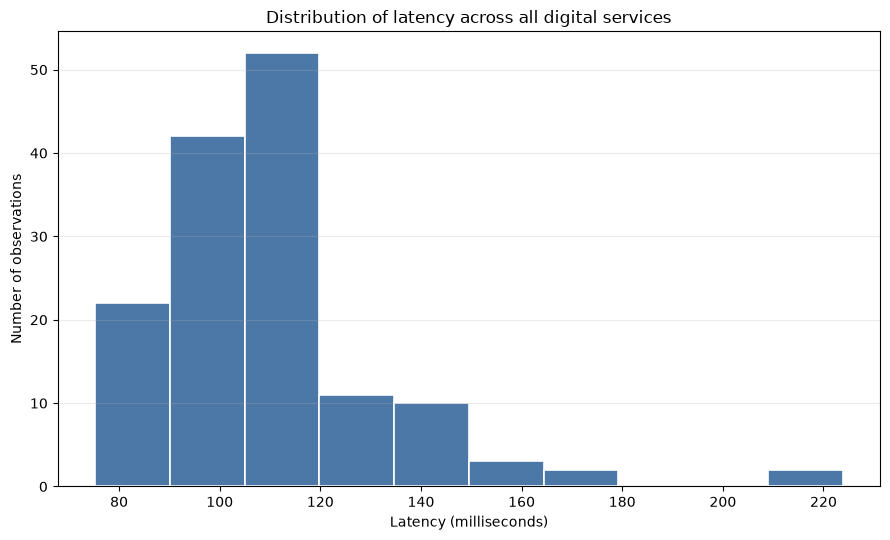

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.hist(
    digital_services["latency_ms"],
    bins=10,
    color="#4C78A8",
    edgecolor="white",
    linewidth=1.2,
)

ax.set_title("Distribution of latency across all digital services")
ax.set_xlabel("Latency (milliseconds)")
ax.set_ylabel("Number of observations")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


### Histogram interpretation

The horizontal axis shows latency in milliseconds, and the vertical axis shows the number of observations. Each bar is a **bin**, meaning an interval of latency values rather than one exact value. The height of a bar is the number of observations whose latency falls inside that interval.

Most observations are concentrated in the lower latency intervals, roughly around 85–125 ms, while a small number of observations extend toward much higher values, up to 223.80 ms. The distribution therefore has a long right tail and appears **right-skewed**. The fact that the overall mean (110.11 ms) is above the median (106.93 ms) is consistent with high values pulling the mean upward. Changing the number of bins could change how detailed the shape looks, although it would not change the observations themselves.


## 1.5 Side-by-side boxplots for the services


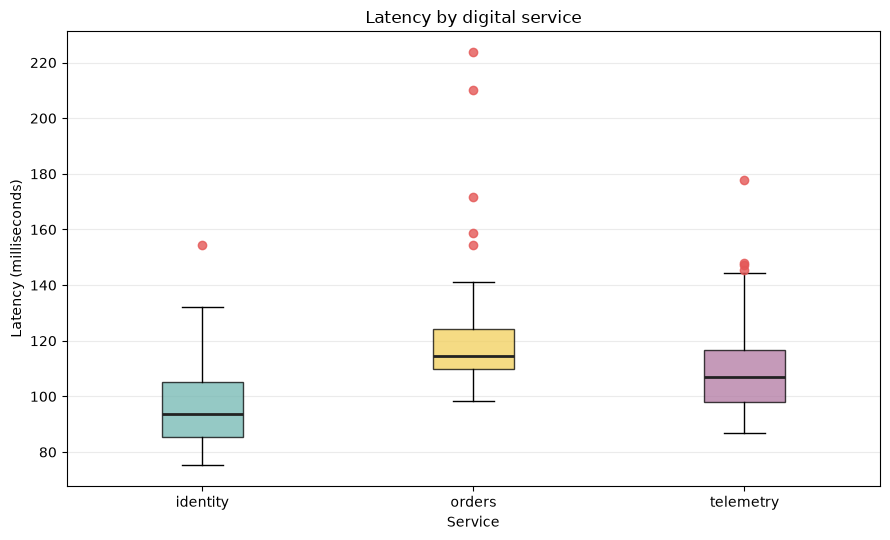

In [10]:
service_order = ["identity", "orders", "telemetry"]
latency_by_service = [
    digital_services.loc[
        digital_services["service"] == service,
        "latency_ms",
    ]
    for service in service_order
]

fig, ax = plt.subplots(figsize=(9, 5.5))

boxplot = ax.boxplot(
    latency_by_service,
    tick_labels=service_order,
    patch_artist=True,
    medianprops={"color": "#222222", "linewidth": 2},
    flierprops={
        "marker": "o",
        "markerfacecolor": "#E45756",
        "markeredgecolor": "#E45756",
        "alpha": 0.8,
    },
)

for box, colour in zip(
    boxplot["boxes"],
    ["#72B7B2", "#F2CF5B", "#B279A2"],
):
    box.set_facecolor(colour)
    box.set_alpha(0.75)

ax.set_title("Latency by digital service")
ax.set_xlabel("Service")
ax.set_ylabel("Latency (milliseconds)")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()


### Boxplot interpretation

The line inside each box is the **median**. The bottom and top of the box are $Q_1$ and $Q_3$, so the box contains the middle 50% of the observations and its height equals the IQR. The whiskers extend to the most extreme observed values that remain within the $1.5\times\operatorname{IQR}$ fences. Individually plotted points beyond the whiskers are **potential outliers**.

Identity has the lowest median, telemetry is in the middle, and orders has the highest median. The upper sides and individually plotted high points are more extended than the lower sides, particularly for orders and telemetry. This visual evidence supports right-skewness. The unusually high points will be identified exactly in the next section rather than estimated from the picture.


## 1.6 Potential outliers using the $1.5\times\operatorname{IQR}$ rule

The fences are calculated separately within each service:

$$\text{Lower fence}=Q_1-1.5(\operatorname{IQR})$$

$$\text{Upper fence}=Q_3+1.5(\operatorname{IQR})$$

An observation below the lower fence or above the upper fence is reported as a potential outlier.


In [11]:
boundary_rows = []
outlier_frames = []

for service, group in digital_services.groupby("service"):
    q1 = group["latency_ms"].quantile(0.25)
    q3 = group["latency_ms"].quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    boundary_rows.append({
        "Service": service,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower fence": lower_fence,
        "Upper fence": upper_fence,
    })

    service_outliers = group.loc[
        (group["latency_ms"] < lower_fence)
        | (group["latency_ms"] > upper_fence),
        ["observation_id", "service", "latency_ms"],
    ].copy()

    service_outliers["Lower fence"] = lower_fence
    service_outliers["Upper fence"] = upper_fence
    outlier_frames.append(service_outliers)


outlier_boundaries = pd.DataFrame(boundary_rows).set_index("Service")
potential_outliers = (
    pd.concat(outlier_frames, ignore_index=True)
    .sort_values(["service", "latency_ms"])
)

print("Service-specific outlier fences:")
display(outlier_boundaries.round(2))

print(f"Potential outliers found: {len(potential_outliers)}")
display(potential_outliers.round(2))


Service-specific outlier fences:


,Q1,Q3,IQR,Lower fence,Upper fence
Service,,,,,
identity,85.39,105.10,19.71,55.83,134.66
orders,109.84,124.15,14.31,88.37,145.61
telemetry,97.95,116.83,18.88,69.63,145.15


Potential outliers found: 10


,observation_id,service,latency_ms,Lower fence,Upper fence
0,132,identity,154.27,55.83,134.66
4,87,orders,154.32,88.37,145.61
3,66,orders,158.59,88.37,145.61
2,60,orders,171.59,88.37,145.61
1,19,orders,210.10,88.37,145.61
5,88,orders,223.80,88.37,145.61
7,39,telemetry,145.52,69.63,145.15
6,33,telemetry,147.26,69.63,145.15
8,120,telemetry,147.79,69.63,145.15
9,133,telemetry,177.87,69.63,145.15


### Outlier results and interpretation

The service-specific IQR rule identifies ten potential outliers, all above their service's upper fence:

- **Identity:** observation 132 (154.27 ms)
- **Orders:** observations 87 (154.32 ms), 66 (158.59 ms), 60 (171.59 ms), 19 (210.10 ms), and 88 (223.80 ms)
- **Telemetry:** observations 39 (145.52 ms), 33 (147.26 ms), 120 (147.79 ms), and 133 (177.87 ms)

The observations are retained in the analysis. A value beyond an IQR fence is not automatically a data error; it is a value that is unusually far from the middle 50% according to this rule. A high latency could be a genuine measurement caused by temporary congestion, server load, a slow dependency or another unusual operating condition. We would need contextual information, logs or evidence of a measurement problem before changing or removing it.


## 1.7 Descriptive comparison of the services

Identity has the lowest observed typical latency: its median is 93.72 ms and its mean is 96.07 ms. Orders has the highest observed typical latency, with a median of 114.53 ms and a mean of 122.20 ms. Telemetry is between these services, with a median of 106.92 ms and a mean of 111.97 ms.

Orders has the largest sample standard deviation (24.81 ms) and range, but the smallest IQR (14.31 ms). Its central observations are therefore relatively concentrated, while its five high potential outliers strongly increase the overall spread. Identity has the smallest standard deviation (16.12 ms), and telemetry has intermediate variability (19.38 ms).

For every service, the mean is higher than the median. Together with the longer upper tails and high potential outliers in the boxplots, this suggests right-skewness, most clearly for orders. These are descriptive differences in the supplied sample. They do not prove what caused the differences, that one service is inherently better, or that exactly the same pattern applies to all future observations or a wider population.


## 1.8 Part 1 conclusion

The 144 digital-service observations show clear descriptive differences among identity, orders and telemetry. Identity had the lowest typical latency, orders the highest, and telemetry lay between them. Orders had the greatest sample standard deviation, although its relatively small IQR shows that much of its additional spread came from high, unusual observations rather than from the middle half of its measurements. The histogram and boxplots indicate right-skewed latency distributions, which is also consistent with each service's mean being higher than its median. The service-specific $1.5\times\operatorname{IQR}$ rule identified ten potential outliers. They were retained because a statistically unusual value can represent genuine service behaviour and is not automatically a recording error. These results summarise the centre, spread and shape of the supplied observations only. Without information about sampling, operating conditions or possible explanatory factors, the analysis cannot establish causes or guarantee that the same differences hold in the wider population.


# Part 2 — Smart-building measurements

> **Placeholder:** Complete this section when `assignment01_smart_building.csv` is available.

## 2.1 Observational unit, variables and grouped summaries

*To be completed.*

## 2.2 Indoor temperature over time

*To be completed.*

## 2.3 Outdoor temperature and energy use

*To be completed.*

## 2.4 Part 2 conclusion

*To be completed.*


# Part 3 — Cybersecurity alert system

> **Placeholder:** Show the probability reasoning manually in Markdown when this part is completed. Python may check arithmetic but should not replace the displayed events, formulas, substitutions and calculations.

## 3.1 Elementary outcomes

*To be completed.*

## 3.2 Expected-count table

*To be completed.*

## 3.3 Probability calculations

*To be completed.*

## 3.4 Conditional probability, independence and mutual exclusivity

*To be completed.*

## 3.5 Improved alert system

*To be completed.*


# Part 4 — AI use and overall conclusion

## AI-use statement

> ChatGPT was used to help structure the notebook, draft and debug Python code, check descriptive calculations, and improve the clarity of written interpretations. The group ran the code against the supplied data, compared the displayed values with the formulas, inspected the plots, corrected suggestions where necessary, and ensured that every member could explain the final work. The group remained responsible for the submitted analysis.

## Overall conclusion

*To be completed after Parts 1–3. The final conclusion should be approximately 150–250 words and include one finding and one limitation from each engineering case.*
